In [1]:

# Importing required libraries 
import numpy as np 
import pandas as pd 
import matplotlib as plt 
from statsmodels.tsa.seasonal import seasonal_decompose 
  
# Read the AirPassengers dataset 
sea_passanger = pd.read_csv('2020-2025.csv',
                            index_col ='Tahun', 
                            parse_dates = True) 
  


C:\Users\athiy\AppData\Local\Temp\ipykernel_18784\75316304.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sea_passanger = pd.read_csv('2020-2025.csv',


In [2]:
# Print the first five rows of the dataset 
sea_passanger
  

,Penumpang
Tahun,
2020-01-01,18821
2020-02-01,14667
2020-03-01,17103
2020-04-01,5024
2020-05-01,2267
...,...
2024-11-01,23251
2024-12-01,25349
2025-01-01,18614


In [3]:
sea_passanger.describe()

,Penumpang
count,63.000000
mean,22934.492063
std,12850.799544
min,2267.000000
25%,13731.000000
50%,19754.000000
75%,32522.000000
max,61649.000000


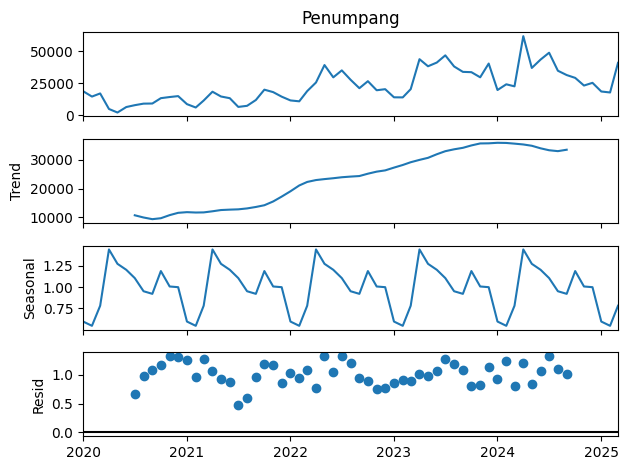

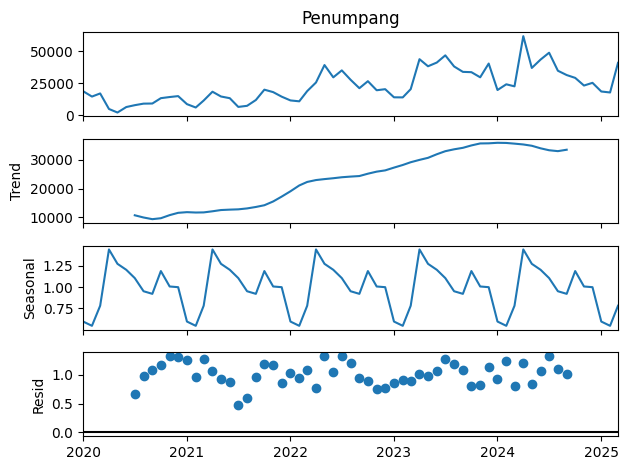

In [4]:
# ETS Decomposition 
result = seasonal_decompose(sea_passanger['Penumpang'],  
                            model ='multiplicative') 
  
# ETS plot  
result.plot() 


In [5]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

df = pd.read_csv('2020-2025.csv')

data_P = pd.DataFrame()
data_P['ds'] = pd.to_datetime(df['Tahun'])
data_P['y'] = df['Penumpang']
data_P.head()


C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
C:\Users\athiy\AppData\Local\Temp\ipykernel_18784\3009500960.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_P['ds'] = pd.to_datetime(df['Tahun'])


,ds,y
0,2020-01-01,18821
1,2020-02-01,14667
2,2020-03-01,17103
3,2020-04-01,5024
4,2020-05-01,2267


In [6]:
m = Prophet()
m.fit(data_P)

10:59:38 - cmdstanpy - INFO - Chain [1] start processing
10:59:39 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
future = m.make_future_dataframe(periods=12 * 2, freq='M')

In [8]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower',
          'yhat_upper', 'trend',
          'trend_lower', 'trend_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper,trend,trend_lower,trend_upper
82,2026-10-31,38463.559897,28704.417107,48331.884362,50499.359724,50499.009063,50499.735205
83,2026-11-30,54432.246304,45575.651982,63819.633811,51000.236383,50999.854730,51000.645197
84,2026-12-31,51646.736188,42988.719518,61166.288021,51517.808932,51517.394193,51518.244216
85,2027-01-31,52164.546470,42563.493371,60977.002376,52035.381481,52034.940140,52035.842416
86,2027-02-28,24887.986654,15298.939503,34110.893448,52502.866363,52502.392681,52503.368675


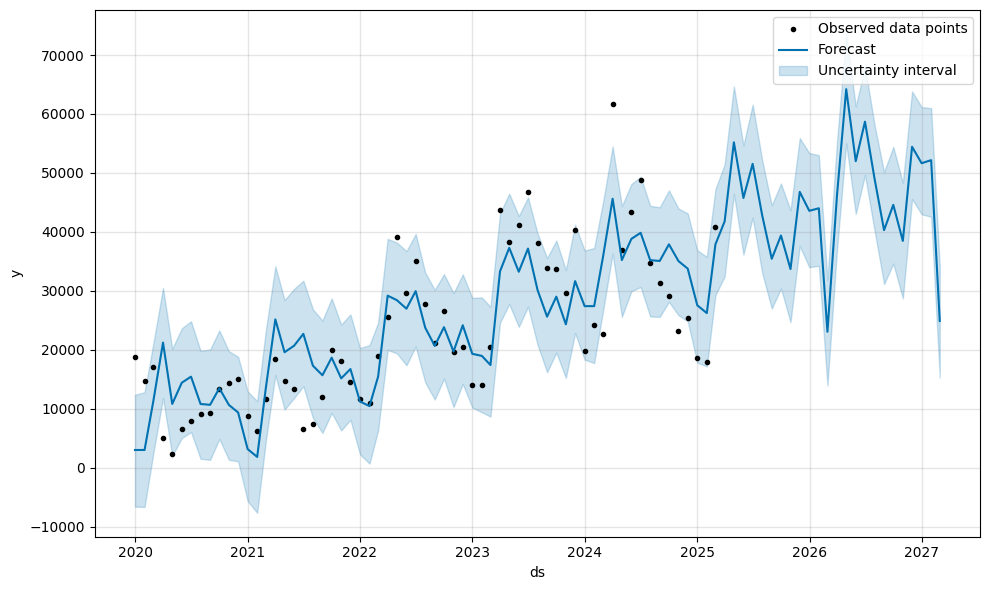

In [9]:
fig1 = m.plot(forecast, include_legend=True)

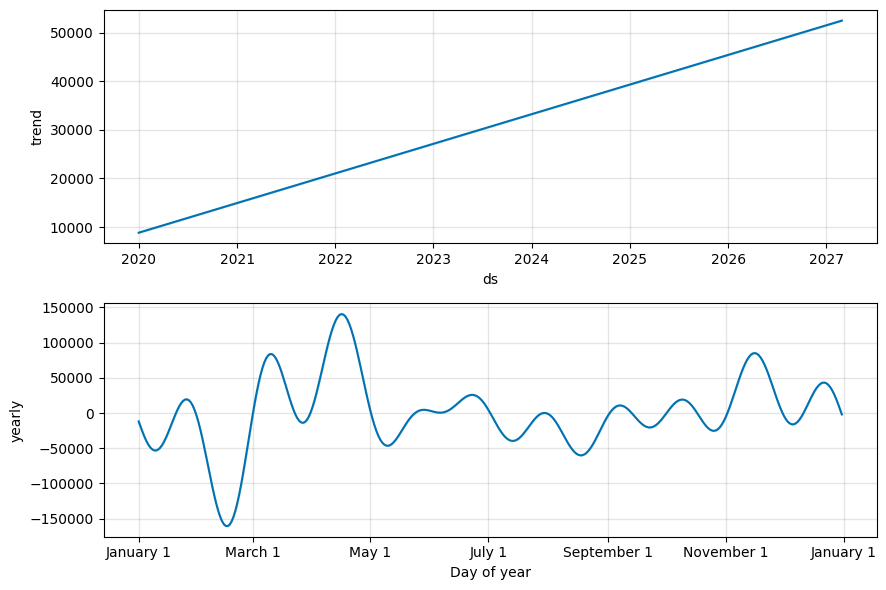

In [10]:
fig2 = m.plot_components(forecast)

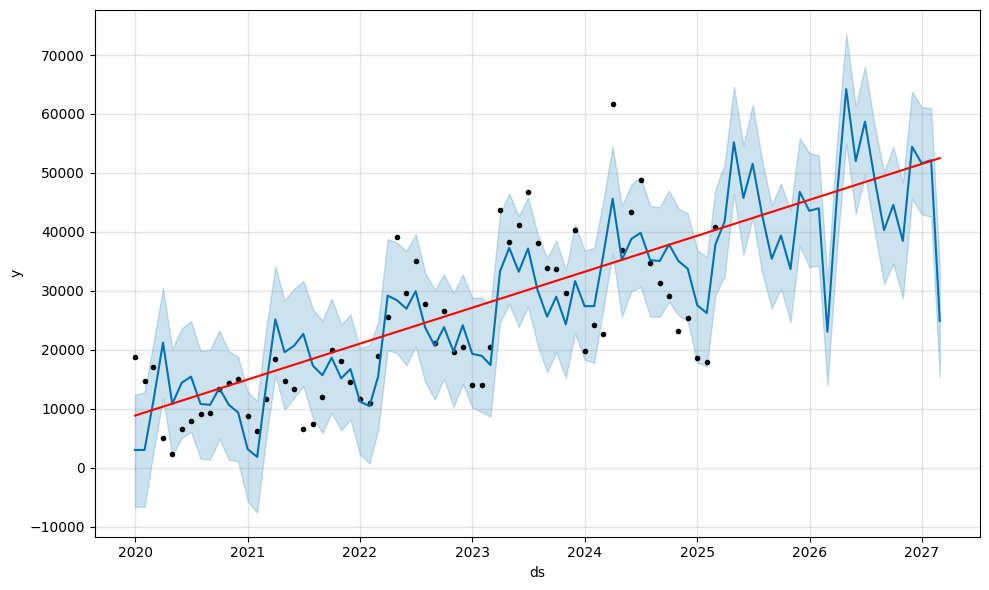

In [17]:
fig3 = m.plot(forecast)
a = add_changepoints_to_plot(fig3.gca(),
                             m, forecast)

In [18]:
from prophet.diagnostics import cross_validation
#df_cv = cross_validation(m, initial='1460 days', period='30 days', horizon = '365 days')

df_cv = cross_validation(m, initial='1460 days', period='365 days', horizon = '30 days')

df_cv

  0%|          | 0/2 [00:00<?, ?it/s]

11:28:27 - cmdstanpy - INFO - Chain [1] start processing
11:28:27 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 1/2 [00:00<00:00,  1.21it/s]11:28:28 - cmdstanpy - INFO - Chain [1] start processing
11:28:28 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 2/2 [00:01<00:00,  1.10it/s]


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2024-02-01,37224.710830,29748.001123,44805.189993,24211,2024-01-31
1,2024-03-01,48040.373370,40412.866135,56275.699465,22623,2024-01-31
2,2025-02-01,31179.312982,21916.767012,39541.407885,17851,2025-01-30
3,2025-03-01,37575.004486,28079.875550,47232.284622,40891,2025-01-30


In [19]:
cutoffs = pd.to_datetime(['2023-01-01', '2023-03-01', '2023-06-01', '2023-09-01', '2023-12-01'])
df_cv2 = cross_validation(m, cutoffs=cutoffs, horizon='365 days')


  0%|          | 0/5 [00:00<?, ?it/s]11:34:04 - cmdstanpy - INFO - Chain [1] start processing
11:34:05 - cmdstanpy - INFO - Chain [1] done processing
 20%|██        | 1/5 [00:00<00:03,  1.22it/s]11:34:05 - cmdstanpy - INFO - Chain [1] start processing
11:34:05 - cmdstanpy - INFO - Chain [1] done processing
 40%|████      | 2/5 [00:01<00:02,  1.30it/s]11:34:06 - cmdstanpy - INFO - Chain [1] start processing
11:34:06 - cmdstanpy - INFO - Chain [1] done processing
 60%|██████    | 3/5 [00:02<00:01,  1.43it/s]11:34:06 - cmdstanpy - INFO - Chain [1] start processing
11:34:07 - cmdstanpy - INFO - Chain [1] done processing
 80%|████████  | 4/5 [00:02<00:00,  1.43it/s]11:34:07 - cmdstanpy - INFO - Chain [1] start processing
11:34:07 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 5/5 [00:03<00:00,  1.45it/s]


In [20]:
from prophet.diagnostics import performance_metrics
df_performance = performance_metrics(df_cv2)
df_performance

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,31 days,2.671713e+08,16345.375335,14739.244452,0.602634,0.429338,0.483807,0.200000
1,59 days,2.576367e+08,16051.065791,14742.409795,0.649418,0.429338,0.547407,0.100000
2,61 days,1.135919e+08,10657.951218,8382.187618,0.336775,0.285800,0.325068,0.400000
3,62 days,8.200244e+07,9055.520030,7495.268095,0.279966,0.285800,0.285391,0.400000
4,90 days,1.196146e+08,10936.845244,8996.150601,0.268609,0.285800,0.267624,0.400000
5,91 days,2.879368e+08,16968.701086,14879.542925,0.522473,0.372344,0.425142,0.133333
6,92 days,2.971923e+08,17239.265743,15686.505764,0.499834,0.368834,0.449379,0.000000
7,120 days,2.504508e+08,15825.638003,13550.833797,0.454681,0.257735,0.385189,0.200000
8,122 days,2.273359e+08,15077.662985,13117.647831,0.410657,0.299271,0.340146,0.400000
9,151 days,2.547643e+08,15961.337976,14593.375531,0.444487,0.301940,0.387815,0.200000


In [15]:
performance_metrics(forecast)

KeyError: 'cutoff'

In [ ]:
# Load specific evaluation tools 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.tools.eval_measures import rmse 

# Calculate root mean squared error 
RMSE = rmse(test["Penumpang"], predictions) 

# Calculate mean squared error 
MSE = mean_squared_error(test["Penumpang"], predictions) 

# Calculate mean absolute error 
MAE = mean_absolute_error(test["Penumpang"], predictions) 

# R squared
R2 = r2_score(test["Penumpang"], predictions) 

# MAPE
MAPE = mean_absolute_percentage_error(test['Penumpang'], predictions)


ValueError: operands could not be broadcast together with shapes (63,) (35,) 

In [ ]:
# Train the model on the full dataset 
model = model = SARIMAX(sea_passanger['Penumpang'], 
						order = (1, 0, 0), 
						seasonal_order =(0, 1, 0, 12)) 
result = model.fit() 

# Forecast for the next 3 years 
forecast = result.predict(start = len(sea_passanger), 
						end = (len(sea_passanger)-1) + 1 * 12, 
						typ = 'levels').rename('Forecast') 

print(forecast)


2024-11-01    26945.657850
2024-12-01    38696.677746
2025-01-01    18745.568602
2025-02-01    23595.542644
2025-03-01    22247.379251
2025-04-01    61419.754309
2025-05-01    36790.088701
2025-06-01    43358.610515
2025-07-01    48721.885809
2025-08-01    34721.194106
2025-09-01    31383.588495
2025-10-01    29193.152934
Freq: MS, Name: Forecast, dtype: float64
